<div style="background-color:#000047; padding: 30px; border-radius: 10px; color: white; text-align: center;">
    <img src='Figures/alinco_white_text.png' style="height: 100px; margin-bottom: 10px;"/>
    <h1>Módulo 1: Preprocesamiento y Representación de Texto</h1>
    <h2>Bag of Words y TF-IDF</h2>
</div>


## 1. Bag of Words 

### ¿Qué es Bag of Words?

**Bag of Words (BoW)** representa cada documento como un **vector de frecuencias** de palabras, ignorando el orden y la gramática.

```
Doc 1: "el gato come pescado"
Doc 2: "el perro come carne"
Doc 3: "el gato juega con el perro"

Vocabulario: [carne, come, con, el, gato, juega, perro, pescado]

Doc 1: [0, 1, 0, 1, 1, 0, 0, 1]
Doc 2: [1, 1, 0, 1, 0, 0, 1, 0]
Doc 3: [0, 0, 1, 2, 1, 1, 1, 0]
```

### Ventajas y limitaciones

| Ventajas | Limitaciones |
|---|---|
| Simple de implementar | Ignora el orden de las palabras |
| Funciona bien para clasificación | Vectores muy dispersos (sparse) |
| Interpretable | No captura semántica |
| Rápido | Las palabras frecuentes dominan |

#### Ejemplo de BoW sin Librerías

In [1]:
import re
import numpy as np
import pandas as pd
from collections import Counter

corpus = [
    "el gato come pescado fresco",
    "el perro come carne y hueso",
    "el gato y el perro juegan juntos",
    "el pescado fresco es delicioso",
    "la carne y el hueso son del perro",
]

def tokenizar(texto):
    return re.findall(r'[a-záéíóúüñ]+', texto.lower())

def construir_vocabulario(corpus):
    vocab = set()
    for doc in corpus:
        vocab.update(tokenizar(doc))
    return sorted(vocab)

def vectorizar_bow(doc, vocab):
   
    return None


MATRIZ BAG OF WORDS (desde cero):
Dimensiones: (5, 16)  →  5 documentos × 16 palabras

      carne  come  del  delicioso  el  es  fresco  gato  hueso  juegan  juntos  la  perro  pescado  son  y
Doc1      0     1    0          0   1   0       1     1      0       0       0   0      0        1    0  0
Doc2      1     1    0          0   1   0       0     0      1       0       0   0      1        0    0  1
Doc3      0     0    0          0   2   0       0     1      0       1       1   0      1        0    0  1
Doc4      0     0    0          1   1   1       1     0      0       0       0   0      0        1    0  0
Doc5      1     0    1          0   1   0       0     0      1       0       0   1      1        0    1  1

Densidad de la matriz: 37.5% (elementos no cero)


In [ ]:
# Construir BoW


## 2. BoW con scikit-learn <a id='bow-sklearn'></a>

In [2]:
from sklearn.feature_extraction.text import CountVectorizer


CountVectorizer — scikit-learn:
  Tipo:      <class 'scipy.sparse._csr.csr_matrix'>
  Shape:     (5, 15)
  Vocabulario (15 palabras):
  ['carne', 'come', 'del', 'delicioso', 'el', 'es', 'fresco', 'gato', 'hueso', 'juegan', 'juntos', 'la', 'perro', 'pescado', 'son']

      carne  come  del  delicioso  el  es  fresco  gato  hueso  juegan  \
Doc1      0     1    0          0   1   0       1     1      0       0   
Doc2      1     1    0          0   1   0       0     0      1       0   
Doc3      0     0    0          0   2   0       0     1      0       1   
Doc4      0     0    0          1   1   1       1     0      0       0   
Doc5      1     0    1          0   1   0       0     0      1       0   

      juntos  la  perro  pescado  son  
Doc1       0   0      0        1    0  
Doc2       0   0      1        0    0  
Doc3       1   0      1        0    0  
Doc4       0   0      0        1    0  
Doc5       0   1      1        0    1  


In [3]:
#  Parámetros importantes de CountVectorizer 
corpus_noticias = [
    "La inteligencia artificial revoluciona la medicina y la salud",
    "El aprendizaje automático mejora los diagnósticos médicos",
    "Python es el lenguaje favorito para ciencia de datos",
    "Los modelos de deep learning aprenden de grandes cantidades de datos",
    "La medicina personalizada usa inteligencia artificial para tratamientos",
    "Ciencia de datos y machine learning transforman las empresas",
]

# min_df: ignorar palabras que aparecen en menos de N documentos
# max_df: ignorar palabras que aparecen en más del X% de documentos
# max_features: solo las N palabras más frecuentes
# ngram_range: bigramas, trigramas

# Bigramas
cv_bigram = CountVectorizer(ngram_range=(1, 2), min_df=1, max_features=20)
X_bigram  = cv_bigram.fit_transform(corpus_noticias)

print("CountVectorizer con BIGRAMAS (top 20 features):")
features = cv_bigram.get_feature_names_out()
sumas    = X_bigram.toarray().sum(axis=0)
top_feat = sorted(zip(features, sumas), key=lambda x: -x[1])[:15]
for feat, freq in top_feat:
    barra = '█' * int(freq)
    print(f"  {feat:<30} {freq:>3} {barra}")

CountVectorizer con BIGRAMAS (top 20 features):
  de                               5 █████
  la                               4 ████
  datos                            3 ███
  de datos                         3 ███
  artificial                       2 ██
  ciencia                          2 ██
  ciencia de                       2 ██
  el                               2 ██
  inteligencia                     2 ██
  inteligencia artificial          2 ██
  la medicina                      2 ██
  learning                         2 ██
  los                              2 ██
  medicina                         2 ██
  para                             2 ██


## 3. TF-IDF (Concepto)

### ¿Qué es TF-IDF?

**TF-IDF** (Term Frequency – Inverse Document Frequency) mide la **importancia de una palabra en un documento relativa al corpus**. Penaliza palabras muy comunes y premia palabras específicas.

#### Term Frequency (TF)

$$TF(t, d) = \frac{\text{número de veces que } t \text{ aparece en } d}{\text{total de términos en } d}$$

#### Inverse Document Frequency (IDF)

$$IDF(t) = \log \left( \frac{N}{df(t)} \right) + 1$$

donde $N$ = número de documentos y $df(t)$ = documentos que contienen $t$.

#### TF-IDF

$$TFIDF(t, d) = TF(t, d) \times IDF(t)$$

### Interpretación

| Caso | TF | IDF | TF-IDF | Significado |
|---|---|---|---|---|
| Palabra muy frecuente en todo el corpus ("el") | Alto | Bajo | Bajo | Stopword — no discrimina |
| Palabra frecuente en UN documento | Alto | Alto | **Alto** | Relevante para ese doc |
| Palabra rara en todo el corpus | Bajo | Alto | Bajo | Ruido |
| Palabra clave específica del doc | Medio | Alto | **Alto** | Muy relevante |

#### Ejemplo de TFIDF Sin librerías

In [4]:
import numpy as np
import pandas as pd
import math

def calcular_tf(tokens):
    """TF = frecuencia del término / total de términos en el doc."""
    total = len(tokens)
    freq = Counter(tokens)
    return {t: c/total for t, c in freq.items()}

def calcular_idf(corpus_tokens):
    """IDF = log(N / df) + 1  : suavizado estilo sklearn."""
    N = len(corpus_tokens)
    df = Counter()
    for tokens in corpus_tokens:
        df.update(set(tokens))
    return {t: math.log(N / count) + 1 for t, count in df.items()}

def calcular_tfidf(corpus):
    corpus_tokens = [tokenizar(doc) for doc in corpus]
    vocab = sorted(set(t for tokens in corpus_tokens for t in tokens))
    idf   = calcular_idf(corpus_tokens)
    matriz = []
    for tokens in corpus_tokens:
        tf = calcular_tf(tokens)
        fila = [round(tf.get(p, 0) * idf.get(p, 0), 4) for p in vocab]
        matriz.append(fila)
    return np.array(matriz), vocab


MATRIZ TF-IDF (desde cero):
Dimensiones: (6, 35)

      aprenden  aprendizaje  artificial  automático  cantidades  ciencia   datos      de    deep  diagnósticos      el  empresas      es  favorito  grandes  inteligencia      la     las  learning  lenguaje     los  machine  medicina  mejora  modelos  médicos    para  personalizada  python  revoluciona   salud  transforman  tratamientos    usa       y
Doc1    0.0000       0.0000      0.2332      0.0000      0.0000   0.0000  0.0000  0.0000  0.0000        0.0000  0.0000    0.0000  0.0000    0.0000   0.0000        0.2332  0.6995  0.0000    0.0000    0.0000  0.0000   0.0000    0.2332  0.0000   0.0000   0.0000  0.0000          0.000  0.0000       0.3102  0.3102       0.0000         0.000  0.000  0.2332
Doc2    0.0000       0.3988      0.0000      0.3988      0.0000   0.0000  0.0000  0.0000  0.0000        0.3988  0.2998    0.0000  0.0000    0.0000   0.0000        0.0000  0.0000  0.0000    0.0000    0.0000  0.2998   0.0000    0.0000  0.3988   0

In [ ]:
# Calcular TF-IDF



In [5]:
# Palabras más importantes por documento  


PALABRAS MÁS IMPORTANTES POR DOCUMENTO (TF-IDF desde cero):
  Doc1: La inteligencia artificial revoluciona la medicina y la...
    Top palabras: ['la', 'revoluciona', 'salud', 'artificial']
  Doc2: El aprendizaje automático mejora los diagnósticos médic...
    Top palabras: ['aprendizaje', 'automático', 'diagnósticos', 'mejora']
  Doc3: Python es el lenguaje favorito para ciencia de datos...
    Top palabras: ['es', 'favorito', 'lenguaje', 'python']
  Doc4: Los modelos de deep learning aprenden de grandes cantid...
    Top palabras: ['de', 'aprenden', 'cantidades', 'deep']
  Doc5: La medicina personalizada usa inteligencia artificial p...
    Top palabras: ['personalizada', 'tratamientos', 'usa', 'artificial']
  Doc6: Ciencia de datos y machine learning transforman las emp...
    Top palabras: ['empresas', 'las', 'machine', 'transforman']


## 4. TF-IDF con scikit-learn 

In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer

#  TfidfVectorizer 



TfidfVectorizer — scikit-learn:
  Shape: (6, 30)
  Sparsity: 76.1% ceros

TOP 5 TÉRMINOS TF-IDF POR DOCUMENTO:
  Doc1: [('la', np.float64(0.704)), ('revoluciona', np.float64(0.409)), ('artificial', np.float64(0.335)), ('inteligencia', np.float64(0.335)), ('medicina', np.float64(0.335))]
  Doc2: [('aprendizaje', np.float64(0.397)), ('automático', np.float64(0.397)), ('diagnósticos', np.float64(0.397)), ('mejora', np.float64(0.397)), ('médicos', np.float64(0.397))]
  Doc3: [('es', np.float64(0.379)), ('favorito', np.float64(0.379)), ('lenguaje', np.float64(0.379)), ('python', np.float64(0.379)), ('ciencia', np.float64(0.31))]
  Doc4: [('de', np.float64(0.486)), ('aprenden', np.float64(0.334)), ('cantidades', np.float64(0.334)), ('deep', np.float64(0.334)), ('grandes', np.float64(0.334))]
  Doc5: [('personalizada', np.float64(0.479)), ('artificial', np.float64(0.393)), ('inteligencia', np.float64(0.393)), ('la', np.float64(0.393)), ('medicina', np.float64(0.393))]
  Doc6: [('empresas', np

In [ ]:
# Top 5 palabras por doc

## 5. Visualización de Matrices de Términos 

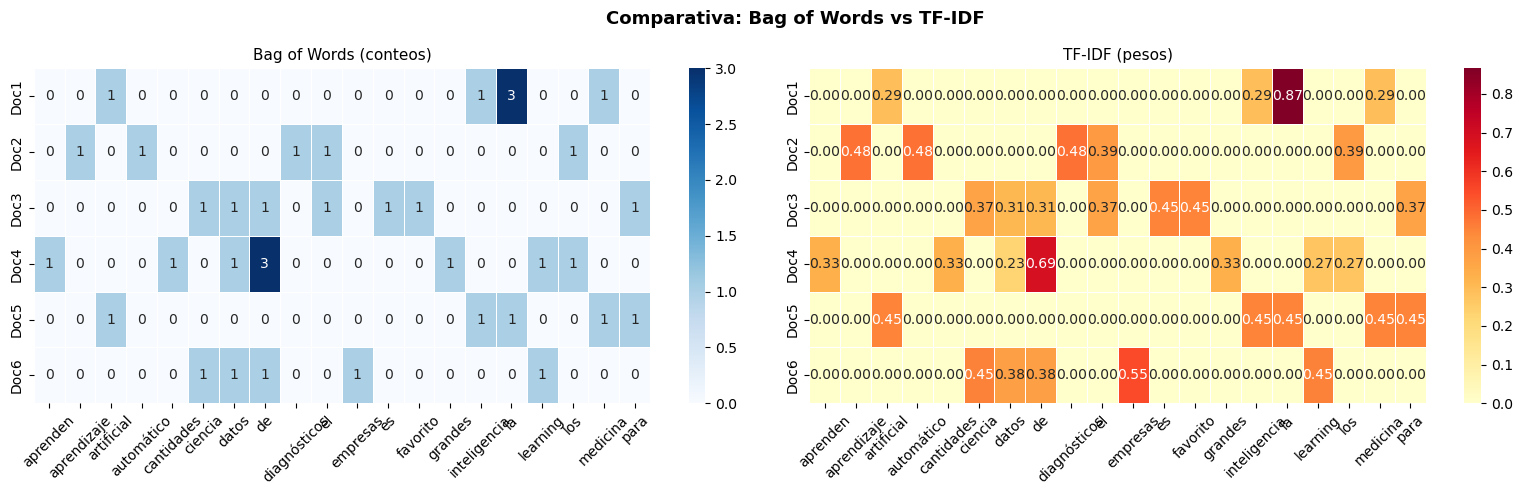

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

#  Heatmap BoW 
X_bow_news = CountVectorizer(max_features=20).fit_transform(corpus_noticias)
cv_news    = CountVectorizer(max_features=20).fit(corpus_noticias)
X_bow_arr  = cv_news.transform(corpus_noticias).toarray()

sns.heatmap(X_bow_arr,
            xticklabels=cv_news.get_feature_names_out(),
            yticklabels=[f'Doc{i+1}' for i in range(len(corpus_noticias))],
            cmap='Blues', annot=True, fmt='d', ax=axes[0], linewidths=0.5)
axes[0].set_title('Bag of Words (conteos)', fontsize=11)
axes[0].tick_params(axis='x', rotation=45)

#  Heatmap TF-IDF 
tv = TfidfVectorizer(max_features=20)
X_tfidf_arr = tv.fit_transform(corpus_noticias).toarray()

sns.heatmap(X_tfidf_arr,
            xticklabels=tv.get_feature_names_out(),
            yticklabels=[f'Doc{i+1}' for i in range(len(corpus_noticias))],
            cmap='YlOrRd', annot=True, fmt='.2f', ax=axes[1], linewidths=0.5)
axes[1].set_title('TF-IDF (pesos)', fontsize=11)
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Comparativa: Bag of Words vs TF-IDF', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Similitud de coseno entre documentos

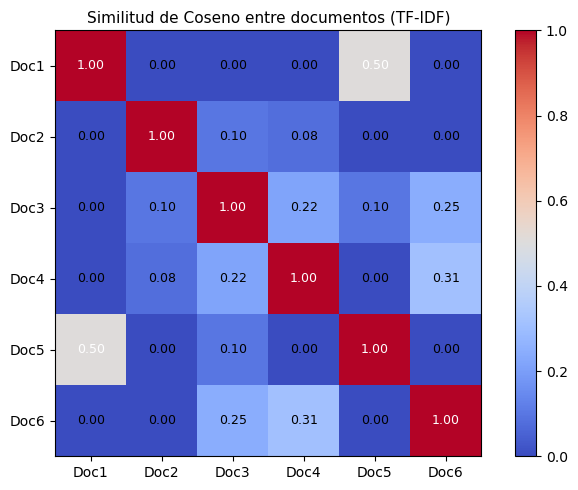


Par más similar: Doc1 ↔ Doc5  (similitud: 0.504)
  Doc1: La inteligencia artificial revoluciona la medicina y la salud
  Doc5: La medicina personalizada usa inteligencia artificial para tratamientos


In [8]:
# ── Similitud de coseno entre documentos ─────────────────────
from sklearn.metrics.pairwise import cosine_similarity


In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(sim_matrix, cmap='coolwarm', vmin=0, vmax=1)
plt.colorbar(im, ax=ax)
labels = [f'Doc{i+1}' for i in range(len(corpus_noticias))]
ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels)
ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels)

for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(j, i, f'{sim_matrix[i,j]:.2f}',
                ha='center', va='center', fontsize=9,
                color='white' if sim_matrix[i,j] > 0.5 else 'black')

ax.set_title('Similitud de Coseno entre documentos (TF-IDF)', fontsize=11)
plt.tight_layout()
plt.show()

# Par más similar
np.fill_diagonal(sim_matrix, 0)
idx = np.unravel_index(sim_matrix.argmax(), sim_matrix.shape)
print(f"\nPar más similar: Doc{idx[0]+1} ↔ Doc{idx[1]+1}  (similitud: {sim_matrix[idx]:.3f})")
print(f"  Doc{idx[0]+1}: {corpus_noticias[idx[0]]}")
print(f"  Doc{idx[1]+1}: {corpus_noticias[idx[1]]}")

## 6. Comparativa: BoW vs TF-IDF

In [9]:
# ── Comparación directa de pesos para la misma palabra ───────
doc_query = ["inteligencia artificial para medicina"]

# BoW
bow_query = cv_news.transform(doc_query).toarray()[0]
# TF-IDF  
tfidf_query = tv.transform(doc_query).toarray()[0]

features = tv.get_feature_names_out()
bow_feats = cv_news.get_feature_names_out()

print("QUERY: 'inteligencia artificial para medicina'")
print()
print("Pesos TF-IDF (palabras de la query en el modelo):")
for i, (f, w) in enumerate(zip(features, tfidf_query)):
    if w > 0:
        print(f"  '{f}': {w:.4f}")

print()

# ── Tabla resumen ─────────────────────────────────────────────
print("TABLA RESUMEN — BoW vs TF-IDF:")
print(f"  {'Característica':<30} {'BoW':<20} {'TF-IDF'}")
print("  " + "-" * 65)
tabla = [
    ("Tipo de peso",          "Conteo frecuencia",   "Frecuencia × rareza"),
    ("Favorece palabras",     "Muy frecuentes",       "Específicas del doc"),
    ("Stopwords",             "Las pondera igual",    "Las penaliza"),
    ("Dimensionalidad",       "|Vocabulario|",        "|Vocabulario|"),
    ("Interpretabilidad",     "Alta",                 "Alta"),
    ("Sensibilidad a escala", "Sí",                   "Reducida (log)"),
]
for fila in tabla:
    print(f"  {fila[0]:<30} {fila[1]:<20} {fila[2]}")

QUERY: 'inteligencia artificial para medicina'

Pesos TF-IDF (palabras de la query en el modelo):
  'artificial': 0.5000
  'inteligencia': 0.5000
  'medicina': 0.5000
  'para': 0.5000

TABLA RESUMEN — BoW vs TF-IDF:
  Característica                 BoW                  TF-IDF
  -----------------------------------------------------------------
  Tipo de peso                   Conteo frecuencia    Frecuencia × rareza
  Favorece palabras              Muy frecuentes       Específicas del doc
  Stopwords                      Las pondera igual    Las penaliza
  Dimensionalidad                |Vocabulario|        |Vocabulario|
  Interpretabilidad              Alta                 Alta
  Sensibilidad a escala          Sí                   Reducida (log)


## 7. Aplicación: Búsqueda por Similitud 

In [10]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# Motor de búsqueda simple con TF-IDF 
class BuscadorTFIDF:
    def __init__(self, corpus):
        self.corpus = None
        self.vectorizer = None
        self.X = None

    def buscar(self, query, top_n=3):
        
        return None



🔍 Query: 'modelos de lenguaje natural'
  [1] score=0.437 | El procesamiento de lenguaje natural analiza texto y discurso
  [2] score=0.235 | Los modelos BERT y GPT transformaron el NLP moderno
  [3] score=0.189 | Los transformers usan mecanismos de atención para el lenguaje

🔍 Query: 'clasificación con machine learning'
  [1] score=0.498 | Python es el lenguaje más popular para machine learning
  [2] score=0.209 | Los algoritmos de deep learning aprenden de grandes datasets

🔍 Query: 'representaciones de palabras vectoriales'
  [1] score=0.786 | Word2Vec aprende representaciones vectoriales de palabras
  [2] score=0.100 | Los algoritmos de deep learning aprenden de grandes datasets
  [3] score=0.054 | El procesamiento de lenguaje natural analiza texto y discurso


In [ ]:
# Corpus más amplio
corpus_busqueda = [
    "La inteligencia artificial mejora el diagnóstico de enfermedades",
    "Python es el lenguaje más popular para machine learning",
    "Los algoritmos de deep learning aprenden de grandes datasets",
    "El procesamiento de lenguaje natural analiza texto y discurso",
    "Los modelos BERT y GPT transformaron el NLP moderno",
    "Scikit-learn facilita la implementación de algoritmos ML",
    "El análisis de sentimientos clasifica opiniones en textos",
    "Word2Vec aprende representaciones vectoriales de palabras",
    "La tokenización es el primer paso en el preprocesamiento NLP",
    "Los transformers usan mecanismos de atención para el lenguaje",
]


queries = [
    "modelos de lenguaje natural",
    "clasificación con machine learning",
    "representaciones de palabras vectoriales",
]
